# Project FLASH V1.2.1 — live demo on the PYNQ-Z2

**Research prototype. Not a medical device.** It is not cleared or validated
for clinical use and must not be used to diagnose, screen or treat anyone.
It shows that a quantised CNN can run bit-exact on a small FPGA.

The accelerator classifies a 224x224 chest X-ray (RSNA pneumonia data) as
pneumonia-positive or negative. Every number below is computed live on this
board: by the FPGA, and for comparison by the ARM CPU running the NumPy golden
model that defines the correct answer.

## Load the overlay and check the board

In [6]:
from pynq import Overlay, allocate, Clocks, MMIO
import numpy as np, time, hashlib, re, sys, os

try:
    import matplotlib.pyplot as plt
    HAVE_MPL = True
except ImportError:
    HAVE_MPL = False
    print('matplotlib not available: images are skipped, tables still print')

# flash_hp64_led = flash_hp64 + an AXI GPIO for the board LEDs (same accelerator)
BIT = 'flash_hp64_led.bit' if os.path.exists('flash_hp64_led.bit') else 'flash_hp64.bit'
HWH = BIT[:-4] + '.hwh'
ol  = Overlay(BIT)
dma = ol.axi_dma_0
acc = ol.top_v1_axi_0

sha = hashlib.sha256(open(BIT, 'rb').read()).hexdigest()[:16]
version = acc.read(0x1C)
fclk = Clocks.fclk0_mhz
print(f'bitstream {BIT}  sha256 {sha}')
print(f'VERSION   {version:#010x}  ({"OK" if version == 0xF1A50102 else "WRONG BITSTREAM"})')
print(f'FCLK0     {fclk:.6f} MHz')
assert version == 0xF1A50102, 'wrong bitstream loaded'

# HP0 AFI width must match the .hwh (see docs/V1_board_debug_log.md). Read only.
hwh_hp0 = int(re.search(r'NAME="PCW_S_AXI_HP0_DATA_WIDTH" VALUE="(\d+)"', open(HWH).read()).group(1))
afi_bit0 = MMIO(0xF8008000, 0x1000).read(0x00) & 1
afi_ok = (afi_bit0 == 1) == (hwh_hp0 == 32)
print(f'AFI       bit0={afi_bit0} ({"32" if afi_bit0 else "64"}-bit), .hwh HP0={hwh_hp0} -> {"OK" if afi_ok else "MISMATCH"}')
if not afi_ok:
    raise RuntimeError('HP0 AFI width does not match the bitstream: reboot the board and re-run')

# ---- fast .mem readers (one hex token per line, LF or CRLF) ----
def read_u8(path):
    return np.frombuffer(bytes.fromhex(''.join(open(path).read().split())), dtype=np.uint8)

def read_s32(path):
    v = np.array([int(t, 16) for t in open(path).read().split()], dtype=np.int64)
    return np.where(v >= 1 << 31, v - (1 << 32), v)

def s32(x):
    return x - (1 << 32) if x & 0x80000000 else x

V = 'vectors/'
E0, E1, EM = read_s32(V + 'exp_logit0.mem'), read_s32(V + 'exp_logit1.mem'), read_s32(V + 'exp_margin.mem')
ED, GT = read_u8(V + 'exp_decision.mem').astype(int), read_u8(V + 'gt_label.mem').astype(int)
THR = -646
img = lambda k: read_u8(f'{V}img_{k}.mem')

buf = allocate(shape=(50176,), dtype=np.uint8)

def run(x, thr=THR):
    # One image on the FPGA -> (logit0, logit1, margin, decision, cycles)
    buf[:] = x
    buf.flush()
    acc.write(0x08, thr & 0xFFFFFFFF)
    acc.write(0x00, 1)
    dma.sendchannel.transfer(buf)
    dma.sendchannel.wait()
    while not (acc.read(0x04) & 0x2):
        pass
    assert not (acc.read(0x04) & 0x8), 'STATUS.err: stream length error'
    return (s32(acc.read(0x0C)), s32(acc.read(0x10)), s32(acc.read(0x14)),
            acc.read(0x18) & 1, acc.read(0x20))

def expected(k):
    return (int(E0[k]), int(E1[k]), int(EM[k]), int(ED[k]))

# ---- board LEDs (axi_gpio_led; no-op if this overlay has none) ----
# ch1 GPIO_DATA 0x00 = LD0..LD3 (bit n = LDn); ch2 GPIO2_DATA 0x08 = RGB LD4/LD5,
# 6 bits "RGBRGB": bit0/1/2 = LD4 blue/green/red, bit3/4/5 = LD5 blue/green/red.
# The board-file ports are tri-state, so both TRI registers (0x04, 0x0C) are set
# to 0 (= output) once here.
LD_ALL, RED, GREEN, BLUE = 0xF, 0x24, 0x12, 0x09
HAVE_LED = 'axi_gpio_led' in ol.ip_dict
if HAVE_LED:
    gpio = MMIO(ol.ip_dict['axi_gpio_led']['phys_addr'], 0x10000)
    gpio.write(0x04, 0); gpio.write(0x0C, 0)
else:
    print('note: no axi_gpio_led in this overlay -> LED code is a no-op')

def leds(ld=0, rgb=0):
    if HAVE_LED:
        gpio.write(0x00, ld); gpio.write(0x08, rgb)

def show_decision(decision):
    # pneumonia: LD0-LD3 blink ~4 Hz for 2.5 s, RGB red; negative: RGB green 1.5 s
    if not HAVE_LED:
        return
    if decision == 1:
        for i in range(20):                    # 20 x 125 ms = 2.5 s, 4 Hz blink
            leds(LD_ALL if i % 2 == 0 else 0, RED)
            time.sleep(0.125)
    else:
        leds(0, GREEN)
        time.sleep(1.5)
    leds(0, 0)
leds(0, 0)

t = time.perf_counter(); _ = img(0); t_parse = (time.perf_counter() - t) * 1e3
print(f'image load: {t_parse:.0f} ms per .mem file')

bitstream flash_hp64_led.bit  sha256 7e0c3394fac1b57d
VERSION   0xf1a50102  (OK)
FCLK0     66.666667 MHz
AFI       bit0=0 (64-bit), .hwh HP0=64 -> OK
image load: 50 ms per .mem file


## LED self-test

LD0-LD3 on for 1 s, then both RGB LEDs red, green and blue for 0.5 s each,
then off. Skipped (with a note) if the overlay has no LED GPIO.

In [8]:
if HAVE_LED:
    print('LD0-LD3 on'); leds(LD_ALL, 0); time.sleep(1.0)
    for name, c in (('red', RED), ('green', GREEN), ('blue', BLUE)):
        print(f'RGB {name}'); leds(0, c); time.sleep(0.5)
    leds(0, 0); print('LEDs off')
else:
    print('no LED GPIO in this overlay: self-test skipped')

LD0-LD3 on
RGB red
RGB green
RGB blue
LEDs off


## Gallery: 12 images, FPGA vs ARM

**Selection rule (fixed in advance, not cherry-picked):** the first 6 true
positives and the first 6 true negatives by image index, from the golden
model's expected decisions against `gt_label.mem`. Each image runs live on the
FPGA and on the ARM golden model. A tick means the FPGA's logits, margin and
decision equal the expected values exactly.

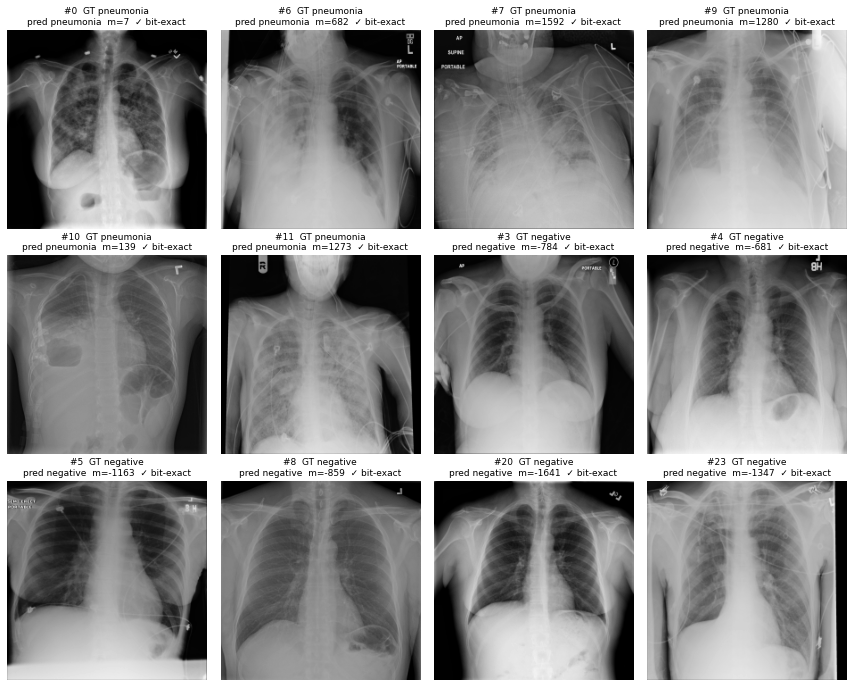

 img        GT      pred  margin exact  FPGA ms   ARM ms  speedup
   0 pneumonia pneumonia       7   yes    185.1    705.2     3.8x
   6 pneumonia pneumonia     682   yes    184.9    731.1     4.0x
   7 pneumonia pneumonia    1592   yes    184.9    699.1     3.8x
   9 pneumonia pneumonia    1280   yes    184.9    710.2     3.8x
  10 pneumonia pneumonia     139   yes    185.0    704.8     3.8x
  11 pneumonia pneumonia    1273   yes    184.9    702.0     3.8x
   3  negative  negative    -784   yes    184.9    706.7     3.8x
   4  negative  negative    -681   yes    184.9    705.2     3.8x
   5  negative  negative   -1163   yes    184.9    701.8     3.8x
   8  negative  negative    -859   yes    185.1    703.7     3.8x
  20  negative  negative   -1641   yes    184.9    704.7     3.8x
  23  negative  negative   -1347   yes    184.9    704.0     3.8x
mean: FPGA 185.0 ms, ARM 706.6 ms, speedup 3.8x;  FPGA bit-exact 12/12, ARM golden == expected 12/12


In [9]:
sys.path.insert(0, 'tools')
from golden_model_v1 import GoldenModel
golden = GoldenModel('model')

LABEL = {1: 'pneumonia', 0: 'negative'}
picks = (list(np.where((ED == 1) & (GT == 1))[0][:6]) +
         list(np.where((ED == 0) & (GT == 0))[0][:6]))
rows = []
for k in picks:
    x = img(k)
    t = time.perf_counter(); r = run(x); t_fpga = (time.perf_counter() - t) * 1e3
    t = time.perf_counter(); lg, _ = golden.run(x.reshape(1, 1, 224, 224)); t_arm = (time.perf_counter() - t) * 1e3
    l0, l1 = int(lg[0, 0]), int(lg[0, 1])
    arm = (l0, l1, l1 - l0, int(l1 - l0 > THR))
    rows.append(dict(k=int(k), x=x, gt=int(GT[k]), fpga=r, arm=arm,
                     exact=r[:4] == expected(k), arm_ok=arm == expected(k),
                     t_fpga=t_fpga, t_arm=t_arm))

if HAVE_MPL:
    fig, axes = plt.subplots(3, 4, figsize=(12, 9.6))
    for ax, rw in zip(axes.flat, rows):
        ax.imshow(rw['x'].reshape(224, 224), cmap='gray', vmin=0, vmax=255)
        ax.set_title(f"#{rw['k']}  GT {LABEL[rw['gt']]}\npred {LABEL[rw['fpga'][3]]}  "
                     f"m={rw['fpga'][2]}  {'✓ bit-exact' if rw['exact'] else '✗ MISMATCH'}", fontsize=9)
        ax.axis('off')
    plt.tight_layout(); plt.show()

print(f"{'img':>4} {'GT':>9} {'pred':>9} {'margin':>7} {'exact':>5} {'FPGA ms':>8} {'ARM ms':>8} {'speedup':>8}")
for rw in rows:
    print(f"{rw['k']:>4} {LABEL[rw['gt']]:>9} {LABEL[rw['fpga'][3]]:>9} {rw['fpga'][2]:>7} "
          f"{'yes' if rw['exact'] else 'NO':>5} {rw['t_fpga']:>8.1f} {rw['t_arm']:>8.1f} {rw['t_arm'] / rw['t_fpga']:>7.1f}x")
tf, ta = np.mean([r['t_fpga'] for r in rows]), np.mean([r['t_arm'] for r in rows])
print(f"mean: FPGA {tf:.1f} ms, ARM {ta:.1f} ms, speedup {ta / tf:.1f}x;  "
      f"FPGA bit-exact {sum(r['exact'] for r in rows)}/12, ARM golden == expected {sum(r['arm_ok'] for r in rows)}/12")

## Live sweep of all 244 verification images

Runs every image on the FPGA (about a minute), then reports bit-exactness against
the golden model and the classification metrics computed from the board's own
margins.

In [10]:
N = 244
board = np.zeros((N, 5), dtype=np.int64)
t0 = time.perf_counter()
for k in range(N):
    board[k] = run(img(k))
    if (k + 1) % 4 == 0 or k + 1 == N:
        print(f'\r{k + 1:3d}/{N}  ({time.perf_counter() - t0:5.1f} s)', end='')
wall = time.perf_counter() - t0
print()

exp_all = np.stack([E0, E1, EM, ED], axis=1)
n_exact = int((board[:, :4] == exp_all).all(axis=1).sum())
m, d = board[:, 2], board[:, 3]
TP = int(((d == 1) & (GT == 1)).sum()); FN = int(((d == 0) & (GT == 1)).sum())
TN = int(((d == 0) & (GT == 0)).sum()); FP = int(((d == 1) & (GT == 0)).sum())
pos, neg = m[GT == 1], m[GT == 0]
auroc = ((pos[:, None] > neg[None, :]).sum() + 0.5 * (pos[:, None] == neg[None, :]).sum()) / (len(pos) * len(neg))

print(f'BIT-EXACT: {n_exact}/{N} (logit0, logit1, margin, decision all equal the golden model)')
print(f'time: {wall:.1f} s total, {wall / N * 1e3:.0f} ms/image incl. .mem loading; '
      f'compute {board[0, 4]} cycles = {board[0, 4] / (fclk * 1e3):.1f} ms/image')
print()
print('                 predicted')
print('                 positive  negative')
print(f'actual positive  {TP:8d}  {FN:8d}')
print(f'actual negative  {FP:8d}  {TN:8d}')
print()
print(f'sensitivity {TP / (TP + FN):.3f}   specificity {TN / (TN + FP):.3f}   '
      f'AUROC {auroc:.4f}   (n = {N}, threshold {THR})')

244/244  ( 56.5 s)
BIT-EXACT: 244/244 (logit0, logit1, margin, decision all equal the golden model)
time: 56.5 s total, 232 ms/image incl. .mem loading; compute 12196126 cycles = 182.9 ms/image

                 predicted
                 positive  negative
actual positive       117         5
actual negative        65        57

sensitivity 0.959   specificity 0.467   AUROC 0.8367   (n = 244, threshold -646)


## Try any image

Move the slider to run any of the 244 images live. Without ipywidgets, set
`IDX` and re-run the cell. On the LED overlay the board shows the decision:
pneumonia = RGB red with LD0-LD3 blinking (2.5 s), negative = RGB green (1.5 s).

In [13]:
def show(k):
    x = img(k)
    t = time.perf_counter(); r = run(x); t_fpga = (time.perf_counter() - t) * 1e3
    ok = r[:4] == expected(k)
    title = (f"#{k}  GT {LABEL[int(GT[k])]}  pred {LABEL[r[3]]}\n"
             f"margin {r[2]}  {'✓ bit-exact' if ok else '✗ MISMATCH'}  {t_fpga:.0f} ms")
    if HAVE_MPL:
        plt.figure(figsize=(4.5, 4.8))
        plt.imshow(x.reshape(224, 224), cmap='gray', vmin=0, vmax=255)
        plt.title(title, fontsize=9); plt.axis('off'); plt.show()
    else:
        print(title)
    show_decision(r[3])          # LEDs: red + blinking LD0-LD3 = pneumonia, green = negative

IDX = 0
try:
    import ipywidgets as widgets
    widgets.interact(show, k=widgets.IntSlider(value=IDX, min=0, max=243, step=1,
                                               continuous_update=False, description='image'))
except ImportError:
    print('ipywidgets not available: set IDX above and re-run this cell')
    show(IDX)
    
# pnemonia images -> 82,170,171

interactive(children=(IntSlider(value=0, continuous_update=False, description='image', max=243), Output()), _d…

## Limitations

- **Specificity is low by design at this threshold.** At T = -646 the
  specificity on these 244 images is 0.467. The threshold was chosen on the
  validation set to reach at least 90% sensitivity (a screening operating
  point), and specificity is the trade-off.
- **The headline accuracy is the test-set AUROC of 0.8229** (V1.2, from the
  training notebook, with its confidence interval). The 244 images are a
  small, seeded, balanced subset used for bit-exactness, not for accuracy
  claims.
- **Speed:** the accelerator does 1 multiply-accumulate per cycle, about
  12.2 M cycles = 183 ms per image at 66.67 MHz. Parallel MACs are future work.
- Below: the first false positive and the first false negative by image index,
  from the live sweep above.

first false positive: image 1, GT negative, pred pneumonia, margin 532 (threshold -646)
first false negative: image 61, GT pneumonia, pred negative, margin -736 (threshold -646)


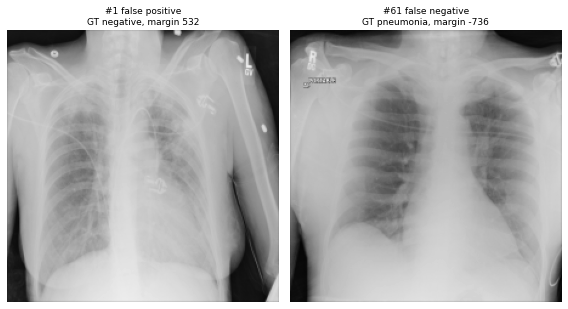

In [14]:
fp_k = int(np.where((board[:, 3] == 1) & (GT == 0))[0][0])
fn_k = int(np.where((board[:, 3] == 0) & (GT == 1))[0][0])
for name, k in (('first false positive', fp_k), ('first false negative', fn_k)):
    print(f'{name}: image {k}, GT {LABEL[int(GT[k])]}, pred {LABEL[int(board[k, 3])]}, '
          f'margin {board[k, 2]} (threshold {THR})')
if HAVE_MPL:
    fig, axes = plt.subplots(1, 2, figsize=(8, 4.6))
    for ax, (name, k) in zip(axes, (('false positive', fp_k), ('false negative', fn_k))):
        ax.imshow(img(k).reshape(224, 224), cmap='gray', vmin=0, vmax=255)
        ax.set_title(f'#{k} {name}\nGT {LABEL[int(GT[k])]}, margin {board[k, 2]}', fontsize=9)
        ax.axis('off')
    plt.tight_layout(); plt.show()

In [15]:
leds(0, 0)
buf.freebuffer()